# Explore differences in parameters between Ariel's mocks and the TFR data



In [1]:
import os
# os.environ['PYTHONNOUSERSITE'] = '1' 
import shutil
import h5py
import fitsio
import pickle
import healpy as hp
import pandas as pd
import numpy as np
import scipy as sp
import time

from itertools import groupby

from csaps import csaps
from scipy.interpolate import PchipInterpolator, UnivariateSpline
from scipy.stats import binned_statistic, multivariate_normal
from scipy.odr import ODR, Model, RealData
from scipy.spatial import KDTree
from scipy import integrate, interpolate, special, stats, optimize
from scipy.optimize import fsolve

#- Global file path for PV analysis.
#  Set to the NERSC folder /global/cfs/cdirs/desi/science/td/pv by default.
#  Set it to something else if working offline.
pvpath = '/global/cfs/cdirs/desi/science/td/pv'
mockpath = '/pscratch/sd/s/sgmoore1/TF/mocks/ariel_mocks/'
tfmockpath = '/global/cfs/cdirs/desi/science/td/pv/mocks/TF_mocks'

from corner import corner
from hyperfit.linfit import LinFit

#- Path to TF_mocks: code for Blanton's k-corrections.
import sys
sys.path.append(tfmockpath)
import TF_photoCorrect as tfpc

from astropy import units as u
from astropy.io import fits
from astropy.table import Table, vstack, join
from astropy.cosmology import Planck18, FlatLambdaCDM, units
from astropy.coordinates import SkyCoord, Distance

from astropy import constants as const
from tqdm import tqdm
from glob import glob
from hdbscan import HDBSCAN
from astroML.plotting import scatter_contour

import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from matplotlib import cm

import fitsio
import numpy.lib.recfunctions as rfn

# cmap = cm.get_cmap('tab10')

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

from sklearn.covariance import EllipticEnvelope
from matplotlib.patches import Ellipse
from scipy.stats import chi2

sys.path.insert(1, '/global/u1/s/sgmoore1/DESI_SGA/TF/')
from hyperfit_v2 import MultiLinFit
from line_fits import hyperfit_line_multi
from help_functions import profile_histogram
from DESI_functions import rz_table, FP_func, omega_m
from TF_photoCorrect import BASS_corr, MW_dust, k_corr, internal_dust
from z_CMB_convert import convert_z_frame
# from DESI_functions import rz_table, FP_func, omega_m


/global/homes/s/sgmoore1/.local/lib/python3.10/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


# Read in catalog

In [2]:
# Snmin=1
# zmax=0.1
# logvmin=0
# logvmax= 3

In [3]:
# mock = Table.read('/pscratch/sd/s/sgmoore1/TF/mocks/ariel_mocks/pure_TF_mock.fits')
# mock = Table.read('/global/cfs/cdirs/desi/science/td/pv/mocks/BGS_base/Ariel_mocks/pure_TF_mock.fits')
# mock = Table.read('/global/cfs/cdirs/desi/science/td/pv/mocks/BGS_base/Ariel_mocks/pure_TF_mock_v0.1.fits')
mock = Table.read('/global/cfs/cdirs/desi/science/td/pv/mocks/BGS_base/Ariel_mocks/pure_TF_mock_v0.2.fits')

In [4]:
mock = mock.to_pandas()

In [5]:
len(mock)

5938776

In [6]:
mpl.rc('font', size=11)

In [7]:
mock[:5]

,ra,dec,halo_ind,halo_mass,is_cen,is_res,vx,vy,vz,zcos,...,app_mag_obs,zmod,zpec_true,eta_true,zpec_approx,effective_radius_no_scatter,effective_radius_true,R26_kpc_true,R26_arcsec_true,R26_arcsec_obs
0,178.248949,-9.383159,34231,1.602902e+11,True,True,608.787537,-274.111450,217.813980,0.102237,...,20.624879,0.107775,-0.002149,-0.010857,-0.002432,3.182505,4.215036,7.368322,3.774026,3.740526
1,170.245474,7.401580,34675,2.151263e+11,True,True,928.104309,207.208328,114.036896,0.103148,...,19.946928,0.107919,-0.002861,-0.014397,-0.003229,3.730646,4.028758,8.813022,4.478836,4.436567
2,168.312560,4.985224,37834,4.513434e+11,True,True,872.097900,-44.169167,273.949646,0.102848,...,18.869965,0.107665,-0.002788,-0.014063,-0.003147,4.752720,4.938474,12.526820,6.382567,6.692171
3,185.515745,7.874739,39741,1.919264e+11,True,True,354.829254,-163.552216,-200.501968,0.101176,...,19.731311,0.107750,-0.001207,-0.006122,-0.001371,3.898541,4.902698,10.120048,5.231392,4.934734
4,182.893252,-3.244018,39883,4.365799e+11,True,True,75.819458,-85.501503,-46.064869,0.100250,...,18.906937,0.107926,-0.000229,-0.001166,-0.000261,4.747089,4.661433,12.108817,6.310467,6.156438


In [8]:
mock.columns

Index(['ra', 'dec', 'halo_ind', 'halo_mass', 'is_cen', 'is_res', 'vx', 'vy',
       'vz', 'zcos', 'zobs', 'schech_abs_mag_no_scatter',
       'tophat_abs_mag_no_scatter', 'abundance_matched_abs_mag_no_scatter',
       'abundance_matched_stellar_mass_no_scatter', 'abs_mag_no_scatter',
       'stellar_mass_no_scatter', 'V_rot_3D_no_scatter', 'inclination',
       'abs_mag_true', 'V_rot_3D_true', 'g-r_true', 'g-r_obs', 'abs_mag_obs',
       'log_V_rot_3D_obs_unc', 'V_rot_3D_obs', 'V_rot_obs', 'dL_true',
       'distmod_true', 'dL_obs', 'distmod_obs', 'app_mag_true', 'app_mag_obs',
       'zmod', 'zpec_true', 'eta_true', 'zpec_approx',
       'effective_radius_no_scatter', 'effective_radius_true', 'R26_kpc_true',
       'R26_arcsec_true', 'R26_arcsec_obs'],
      dtype='object')

## Iron Data + SGA Catalog
Add column names consistent with what are used in the DR1 TF Mocks

In [9]:
# mock['LOGVROT_MOCK'] = mock['log_V_V0'] + 2.11
# mock['R_ABSMAG_SB26_MOCK'] = mock['M_abs']
# mock['LOGVROT_ERR_MOCK'] = mock['log_V_V0_unc']
# mock['R_ABSMAG_SB26_ERR_MOCK'] = mock['M_abs_unc']

### switch to prior name conventions for convenience
# mock['LOGVROT_MOCK'] = np.log10(mock['V_rot_obs'])
mock['LOGVROT_MOCK'] = np.log10(mock['V_rot_3D_obs'])
mock['R_ABSMAG_SB26_MOCK'] = mock['abs_mag_obs']
# mock['LOGVROT_ERR_MOCK'] = mock['log_V_V0_unc']
# mock['R_ABSMAG_SB26_ERR_MOCK'] = mock['M_abs_unc']
mock['D26'] = 2*mock['R26_arcsec_obs']/60

In [10]:
mock['LOGVROT_ERR_MOCK'] = mock['log_V_rot_3D_obs_unc']
# mock['LOGVROT_ERR_MOCK'] = 0.03
mock['R_ABSMAG_SB26_ERR_MOCK'] = 0.03
mock['Sn'] = 1

In [11]:
# mock = mock[mock['R26_arcsec_true'] > 10]

In [12]:
mock[:5]

,ra,dec,halo_ind,halo_mass,is_cen,is_res,vx,vy,vz,zcos,...,effective_radius_true,R26_kpc_true,R26_arcsec_true,R26_arcsec_obs,LOGVROT_MOCK,R_ABSMAG_SB26_MOCK,D26,LOGVROT_ERR_MOCK,R_ABSMAG_SB26_ERR_MOCK,Sn
0,178.248949,-9.383159,34231,1.602902e+11,True,True,608.787537,-274.111450,217.813980,0.102237,...,4.215036,7.368322,3.774026,3.740526,1.790967,-17.768529,0.124684,0.05,0.03,1
1,170.245474,7.401580,34675,2.151263e+11,True,True,928.104309,207.208328,114.036896,0.103148,...,4.028758,8.813022,4.478836,4.436567,1.936427,-18.449350,0.147886,0.05,0.03,1
2,168.312560,4.985224,37834,4.513434e+11,True,True,872.097900,-44.169167,273.949646,0.102848,...,4.938474,12.526820,6.382567,6.692171,2.008055,-19.521228,0.223072,0.05,0.03,1
3,185.515745,7.874739,39741,1.919264e+11,True,True,354.829254,-163.552216,-200.501968,0.101176,...,4.902698,10.120048,5.231392,4.934734,1.984913,-18.661595,0.164491,0.05,0.03,1
4,182.893252,-3.244018,39883,4.365799e+11,True,True,75.819458,-85.501503,-46.064869,0.100250,...,4.661433,12.108817,6.310467,6.156438,1.993807,-19.489476,0.205215,0.05,0.03,1


In [13]:
np.min(mock['V_rot_obs'])

0.03718968482305317

### Apply TF Selection Cuts

Here apply the late-type galaxy cuts defined in *Target Selection for the DESI Peculiar Velocity Survey*, C. Saulder+, MNRAS 525:1106, 2023. Note that several cuts are the complement of the early-type cuts for the FP sample.

**For this version, we are not applying any selection cuts or weights**

In [14]:
mock_full = mock
mock = mock[mock['R26_arcsec_true'] > 10]

### Set up the Cosmology

Use a flat-$\Lambda$CDM fiducial cosmology with $H_0\equiv100$ km/s/Mpc and $\Omega_m=0.3151$.

In [15]:
h = 1
cosmology = FlatLambdaCDM(H0=100*h, Om0=0.3151)

#### Calculate distances to galaxies based on this cosmology
This will be useful in determining the selection effects

In [16]:
dist = Distance(z=np.abs(mock['zobs']), cosmology=cosmology)
mock['D26_kpc'] = 2*dist.to('kpc')*np.tan(0.5*mock['D26'].values*u.arcmin)

/tmp/ipykernel_2003767/3814900504.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mock['D26_kpc'] = 2*dist.to('kpc')*np.tan(0.5*mock['D26'].values*u.arcmin)


### Current Y1 TFR Best Fit

TF Y1 best-fit parameters and covariances, corresponding to v9 of the TF Y1 catalog. This comes from the TFR calibration using 7 galaxy clusters (2025-03-28) using Vmax weights to account for the galaxy size function. The TFR fit is

$$
M_r = a \log_{10}{\left(\frac{V_\mathrm{rot}}{V_0}\right)} + b_{0\mathrm{pt}}
$$

with intrinsic scatter $\sigma$ along the magnitude axis. See this [notebook](https://github.com/DESI-UR/DESI_SGA/blob/master/TF/Y1/TF_Y1_cluster_calibration_AnthonyUpdates_weightsVmax-1_KAD.ipynb) in the [DESI_SGA/TF/Y1](https://github.com/DESI-UR/DESI_SGA/tree/master/TF/Y1) GitHub repo.

The parameter vector includes the TFR slope $a$, global zero point $b_{0\text{pt}}$, calibration cluster intercepts $\{b_i\}$, and intrinsic scatter $\sigma$.

### Current TFR Catalog

Read in the TFR catalog to sample uncertainties in $V_\mathrm{rot}$.

In [17]:
tfr_version = 'v10'

# tfrcatfile = os.path.join(pvpath, f'tfgalaxies/Y1/DESI-DR1_TF_pv_cat_{tfr_version}.fits')
# tfrcatfile = os.path.join(pvpath, f'tfgalaxies/Y1/systematic_tests/DESI-DR1_TF_pv_test_cat_{tfr_version}.fits')
tfrcatfile='/pscratch/sd/s/sgmoore1/TF/cats/SGA_iron_2dGaussian_030426.fits'
tfrcat = Table.read(tfrcatfile)
tfr_params = fits.open(tfrcatfile)
#- Set minimum velocity uncertainty to 7 km/s.
# lowverr = tfrcat['V_0p4R26_ERR'] < 7.
# tfrcat['V_0p4R26_ERR'][lowverr] = 7.

tfrcat['logv_rot'] = np.log10(tfrcat['V_0p4R26'])
tfrcat['logv_rot_err'] = 0.434*tfrcat['V_0p4R26_ERR'] / tfrcat['V_0p4R26']

tfrcat = tfrcat['Z_DESI', 'D26', 'G_MAG_SB26_CORR', 'R_MAG_SB26_CORR', 'R_MAG_SB26_ERR_CORR', 'R_ABSMAG_SB26', 'LOGDIST', 'LOGDIST_ERR', 'MU_ZCMB', 'MU_ZCMB_ERR', 'V_0p4R26', 'V_0p4R26_ERR', 'logv_rot', 'logv_rot_err', 'MAIN'].to_pandas()
tfrcat['R_ABSMAG_SB26_ERR'] = tfrcat['R_MAG_SB26_ERR_CORR']
tfrcat

,Z_DESI,D26,G_MAG_SB26_CORR,R_MAG_SB26_CORR,R_MAG_SB26_ERR_CORR,R_ABSMAG_SB26,LOGDIST,LOGDIST_ERR,MU_ZCMB,MU_ZCMB_ERR,V_0p4R26,V_0p4R26_ERR,logv_rot,logv_rot_err,MAIN,R_ABSMAG_SB26_ERR
0,0.080990,0.417579,17.124643,16.715231,0.109794,-20.355425,0.105432,0.124338,37.070655,0.000752,122.322388,10.869519,2.087506,0.038565,True,0.109794
1,0.044002,0.495681,17.260061,16.876765,0.087894,-18.849686,0.059728,0.069318,35.726451,0.001289,81.348133,6.577976,1.910348,0.035094,True,0.087894
2,0.090040,0.567250,16.552837,15.939736,0.113037,-21.385827,0.064874,0.120452,37.325563,0.000978,180.655725,13.281536,2.256852,0.031907,True,0.113037
3,0.034026,0.575771,16.879276,16.643692,0.098862,-18.507536,0.078685,0.071507,35.151228,0.001619,70.102003,12.043673,1.845730,0.074562,True,0.098862
4,0.043319,0.953031,15.737734,15.209917,0.143845,-20.465230,0.070619,0.123828,35.675148,0.001354,133.778523,10.944416,2.126386,0.035506,True,0.143845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10195,0.116921,0.369286,17.064823,16.648229,0.078975,-21.256834,0.444994,0.136799,37.905063,0.000531,95.032991,12.384687,1.977874,0.056559,False,0.078975
10196,0.054449,0.376227,17.548884,17.080274,0.045130,-19.081032,0.369959,0.137208,36.161306,0.001144,44.540700,19.033877,1.648757,0.185464,True,0.045130
10197,0.118856,0.362001,18.136868,17.638431,0.071668,-20.307229,0.099486,0.156327,37.945660,0.001205,123.942591,22.458671,2.093221,0.078642,True,0.071668
10198,0.133822,0.454465,18.323800,17.365721,0.139803,-20.857233,-0.007474,0.130805,38.222953,0.000729,172.888233,18.437635,2.237765,0.046284,True,0.139803


In [18]:
tfrcat['g-r'] = tfrcat['G_MAG_SB26_CORR']- tfrcat['R_MAG_SB26_CORR']

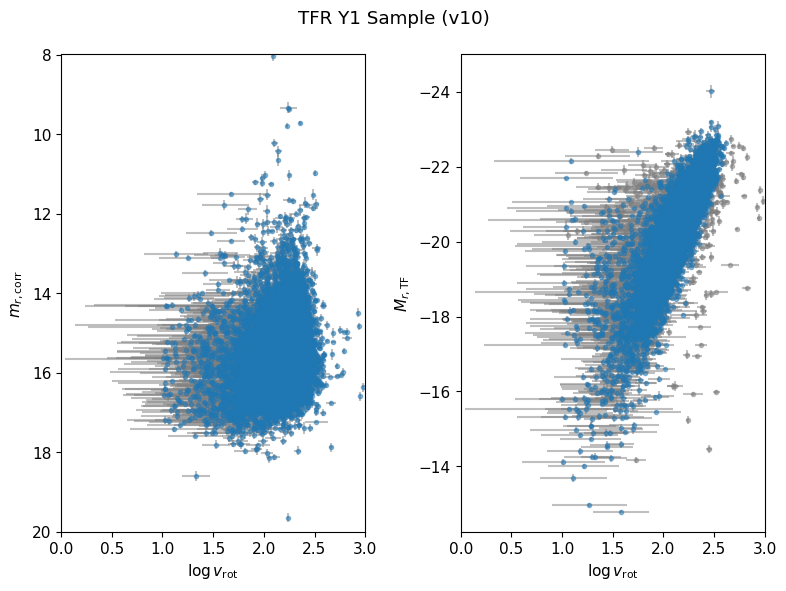

In [19]:
fig, axes = plt.subplots(1,2, figsize=(8,6), tight_layout=True, sharex=True)

ax = axes[0]
ax.errorbar(tfrcat['logv_rot'], tfrcat['R_MAG_SB26_CORR'],
             xerr=tfrcat['logv_rot_err'],
             yerr=tfrcat['R_MAG_SB26_ERR_CORR'],
             fmt='.', 
             alpha=0.5, 
             ecolor='gray')

ax.set(xlim=(0,3),
       xlabel=r'$\log{v_\mathrm{rot}}$',
       ylabel=r'$m_{r,\mathrm{corr}}$',
       ylim=(20,8))

ax = axes[1]
ax.errorbar(tfrcat['logv_rot'][~tfrcat['MAIN']], tfrcat['R_ABSMAG_SB26'][~tfrcat['MAIN']],
             xerr=tfrcat['logv_rot_err'][~tfrcat['MAIN']],
             yerr=tfrcat['R_ABSMAG_SB26_ERR'][~tfrcat['MAIN']],
             fmt='.', 
             color='gray',
             alpha=0.5, 
             ecolor='gray')

ax.errorbar(tfrcat['logv_rot'][tfrcat['MAIN']], tfrcat['R_ABSMAG_SB26'][tfrcat['MAIN']],
             xerr=tfrcat['logv_rot_err'][tfrcat['MAIN']],
             yerr=tfrcat['R_ABSMAG_SB26_ERR'][tfrcat['MAIN']],
             fmt='.', 
             alpha=0.5, 
             ecolor='gray')

ax.set(xlim=(0,3),
       xlabel=r'$\log{v_\mathrm{rot}}$',
       ylabel=r'$M_{r,\mathrm{TF}}$',
       ylim=(-12.25, -25))

fig.suptitle(f'TFR Y1 Sample ({tfr_version})')
fig.set_facecolor('none');
# fig.savefig('tfr_y1_sample.png', dpi=180);

#### Downsample the mock to comparable sizes to data sample

In [20]:
def downsample(mock, size=100):
    """Randomly downsample a mock catalog, without replacement, to some size.

    Parameters
    ----------
    mock: pandas.DataFrame
        Pandas table with a mock catalog.
    size: int
        Size of the final downsampled catalog.

    Returns
    -------
    newmock: pandas.DataFrame
        Downsampled Pandas table.
    """
    Nmock = len(mock)
    idx_downsample = np.random.choice(Nmock, size, replace=False)
    return mock.iloc[idx_downsample]

def resample(mock, data, size=100, mag_col_mock='R_ABSMAG_SB26_MOCK',
             mag_col_data='R_ABSMAG_SB26', bins=20, random_state=None):
    """
    Downsample a mock catalog to match the absolute magnitude distribution
    of a data catalog.

    Parameters
    ----------
    mock : pandas.DataFrame
        Mock catalog.
    data : pandas.DataFrame
        Data catalog (e.g., tfrcat).
    size : int
        Desired number of objects in output sample.
    mag_col_mock : str
        Column name for absolute magnitude in mock.
    mag_col_data : str
        Column name for absolute magnitude in data.
    bins : int or array-like
        Number of bins or bin edges for magnitude.
    random_state : int or None
        Random seed.

    Returns
    -------
    newmock : pandas.DataFrame
        Resampled mock catalog matching data distribution.
    """

    rng = np.random.default_rng(random_state)

    # Drop NaNs
    mock_vals = mock[mag_col_mock].values
    data_vals = data[mag_col_data].values

    valid_mock = np.isfinite(mock_vals)
    valid_data = np.isfinite(data_vals)

    mock = mock.loc[valid_mock].copy()
    data_vals = data_vals[valid_data]

    # Define bins based on data
    hist_data, bin_edges = np.histogram(data_vals, bins=bins)

    # Convert to probabilities
    prob_data = hist_data / hist_data.sum()

    # Assign each mock galaxy to a bin
    mock_bins = np.digitize(mock[mag_col_mock], bin_edges) - 1

    sampled_indices = []

    for i in range(len(bin_edges) - 1):
        # indices in this bin
        idx_in_bin = np.where(mock_bins == i)[0]

        if len(idx_in_bin) == 0:
            continue

        # number to draw from this bin
        n_draw = int(np.round(prob_data[i] * size))

        if n_draw == 0:
            continue

        # sample (without replacement if possible)
        replace = n_draw > len(idx_in_bin)
        chosen = rng.choice(idx_in_bin, size=n_draw, replace=replace)

        sampled_indices.extend(chosen)

    # If we are short/excess due to rounding, fix it
    if len(sampled_indices) < size:
        remaining = size - len(sampled_indices)
        extra = rng.choice(len(mock), size=remaining, replace=False)
        sampled_indices.extend(extra)
    elif len(sampled_indices) > size:
        sampled_indices = rng.choice(sampled_indices, size=size, replace=False)

    return mock.iloc[sampled_indices].reset_index(drop=True)

#### Plot $M_{R,\mathrm{SB26}}$ for Mocks and TFR Data

Make a side-by-side comparison of the (downsampled) mock catalog and Y1 data.

Apply the quality cuts equally to both.

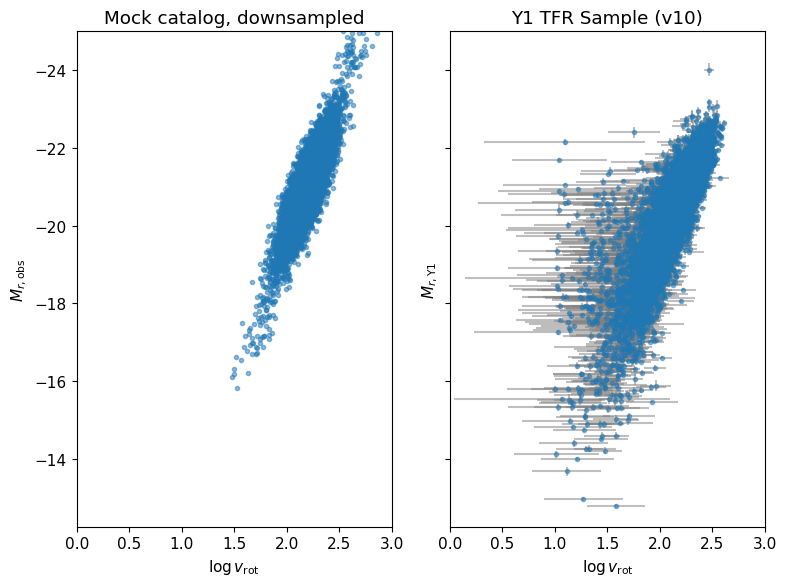

In [21]:
#- Plot Mr vs log(v_rot) for the various steps in the calculation.

fig, axes = plt.subplots(1,2, figsize=(8,6), tight_layout=True, sharex=True, sharey=True)

Ntfr = len(tfrcat[tfrcat['MAIN']])
mock_downsample = downsample(mock, Ntfr)

ax = axes[0]
ax.errorbar(mock_downsample['LOGVROT_MOCK'], mock_downsample['R_ABSMAG_SB26_MOCK'],
            # xerr=mock_downsample['LOGVROT_ERR_MOCK'],
            # yerr=mock_downsample['R_ABSMAG_SB26_ERR_MOCK'],
            fmt='.', 
            alpha=0.5, 
            ecolor='gray')

# idx_mock_goodv = alex_cuts_velocity(mock_downsample, logv_name='LOGVROT_MOCK', distmod_name='MU_OBS_MOCK')
# idx_mock_notdwarf = alex_cuts_dwarf(mock_downsample, rmag_name='R_MAG_SB26_CORR', distmod_name='MU_OBS_MOCK')
# idx_mock_good = idx_mock_goodv & idx_mock_notdwarf

# idx_tfr_good, idx_mock_good = ellipse_fit(tfrcat['logv_rot'], tfrcat['R_ABSMAG_SB26'], mock_downsample['LOGVROT_MOCK'], mock_downsample['R_ABSMAG_SB26_MOCK'])
# idx_mock_good = ellipse_boolean(mock_downsample['LOGVROT_MOCK'], mock_downsample['R_ABSMAG_SB26_MOCK'], ellipse_mean, ellipse_cov, n_std=ellipse_sigma)

# ax.errorbar(mock_downsample['LOGVROT_MOCK'][idx_mock_good], mock_downsample['R_ABSMAG_SB26_MOCK'][idx_mock_good],
#              xerr=mock_downsample['LOGVROT_ERR_MOCK'][idx_mock_good],
#              yerr=mock_downsample['R_ABSMAG_SB26_ERR_MOCK'][idx_mock_good],
#              fmt='.', 
#              alpha=0.5, 
#              ecolor='gray')

ax.set(xlim=(0,3),
       xlabel=r'$\log{v_\mathrm{rot}}$',
       ylabel=r'$M_{r,\mathrm{obs}}$',
       ylim=(-12.25, -25),
       title=r'Mock catalog, downsampled')

ax = axes[1]
ax.errorbar(tfrcat['logv_rot'][tfrcat['MAIN']], tfrcat['R_ABSMAG_SB26'][tfrcat['MAIN']],
             xerr=tfrcat['logv_rot_err'][tfrcat['MAIN']],
             yerr=tfrcat['R_ABSMAG_SB26_ERR'][tfrcat['MAIN']],
             fmt='.', 
             alpha=0.5, 
             ecolor='gray')

# idx_tfr_goodv = alex_cuts_velocity(tfrcat, logv_name='logv_rot', distmod_name='MU_ZCMB')
# idx_tfr_notdwarf = alex_cuts_dwarf(tfrcat, rmag_name='R_MAG_SB26_CORR', distmod_name='MU_ZCMB')
# idx_tfr_good = idx_tfr_goodv & idx_tfr_notdwarf
# idx_tfr_good = ellipse_boolean(tfrcat['logv_rot'], tfrcat['R_ABSMAG_SB26'], ellipse_mean, ellipse_cov, n_std=ellipse_sigma)

# ax.errorbar(tfrcat['logv_rot'][idx_tfr_good], tfrcat['R_ABSMAG_SB26'][idx_tfr_good],
#              xerr=tfrcat['logv_rot_err'][idx_tfr_good],
#              yerr=tfrcat['R_ABSMAG_SB26_ERR'][idx_tfr_good],
#              fmt='.', 
#              alpha=0.5, 
#              ecolor='gray')

ax.set(xlim=(0,3),
       xlabel=r'$\log{v_\mathrm{rot}}$',
       ylabel=r'$M_{r,\mathrm{Y1}}$',
       ylim=(-12.25, -25),
       title=f'Y1 TFR Sample ({tfr_version})');

fig.set_facecolor('none');
# fig.savefig('tfr_mock_mr_vs_logv.png', dpi=150);

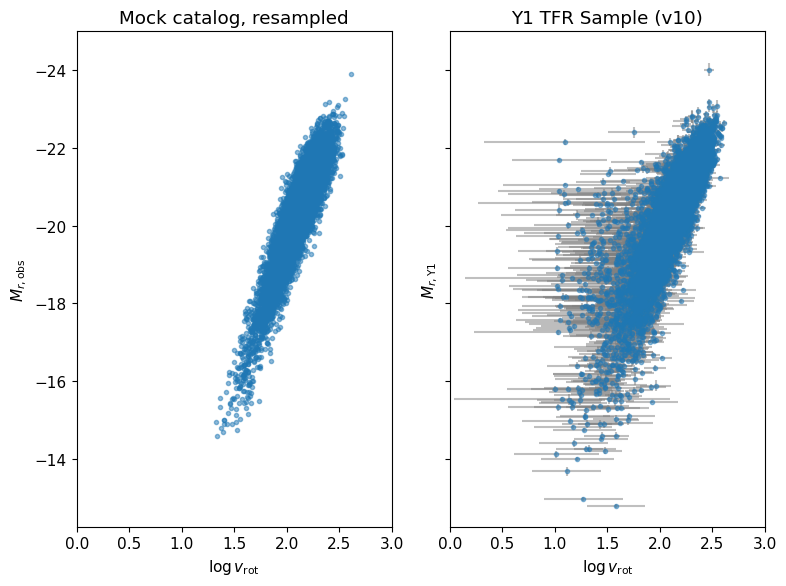

In [22]:
#- Plot Mr vs log(v_rot) for the various steps in the calculation.

fig, axes = plt.subplots(1,2, figsize=(8,6), tight_layout=True, sharex=True, sharey=True)

# Ntfr = len(tfrcat)
mock_resample = resample(mock, tfrcat[tfrcat['MAIN']], Ntfr)

ax = axes[0]
ax.errorbar(mock_resample['LOGVROT_MOCK'], mock_resample['R_ABSMAG_SB26_MOCK'],
            # xerr=mock_downsample['LOGVROT_ERR_MOCK'],
            # yerr=mock_downsample['R_ABSMAG_SB26_ERR_MOCK'],
            fmt='.', 
            alpha=0.5, 
            ecolor='gray')

# idx_mock_goodv = alex_cuts_velocity(mock_downsample, logv_name='LOGVROT_MOCK', distmod_name='MU_OBS_MOCK')
# idx_mock_notdwarf = alex_cuts_dwarf(mock_downsample, rmag_name='R_MAG_SB26_CORR', distmod_name='MU_OBS_MOCK')
# idx_mock_good = idx_mock_goodv & idx_mock_notdwarf

# idx_tfr_good, idx_mock_good = ellipse_fit(tfrcat['logv_rot'], tfrcat['R_ABSMAG_SB26'], mock_downsample['LOGVROT_MOCK'], mock_downsample['R_ABSMAG_SB26_MOCK'])
# idx_mock_good = ellipse_boolean(mock_downsample['LOGVROT_MOCK'], mock_downsample['R_ABSMAG_SB26_MOCK'], ellipse_mean, ellipse_cov, n_std=ellipse_sigma)

# ax.errorbar(mock_downsample['LOGVROT_MOCK'][idx_mock_good], mock_downsample['R_ABSMAG_SB26_MOCK'][idx_mock_good],
#              xerr=mock_downsample['LOGVROT_ERR_MOCK'][idx_mock_good],
#              yerr=mock_downsample['R_ABSMAG_SB26_ERR_MOCK'][idx_mock_good],
#              fmt='.', 
#              alpha=0.5, 
#              ecolor='gray')

ax.set(xlim=(0,3),
       xlabel=r'$\log{v_\mathrm{rot}}$',
       ylabel=r'$M_{r,\mathrm{obs}}$',
       ylim=(-12.25, -25),
       title=r'Mock catalog, resampled')

ax = axes[1]
ax.errorbar(tfrcat['logv_rot'][tfrcat['MAIN']], tfrcat['R_ABSMAG_SB26'][tfrcat['MAIN']],
             xerr=tfrcat['logv_rot_err'][tfrcat['MAIN']],
             yerr=tfrcat['R_ABSMAG_SB26_ERR'][tfrcat['MAIN']],
             fmt='.', 
             alpha=0.5, 
             ecolor='gray')

# idx_tfr_goodv = alex_cuts_velocity(tfrcat, logv_name='logv_rot', distmod_name='MU_ZCMB')
# idx_tfr_notdwarf = alex_cuts_dwarf(tfrcat, rmag_name='R_MAG_SB26_CORR', distmod_name='MU_ZCMB')
# idx_tfr_good = idx_tfr_goodv & idx_tfr_notdwarf
# idx_tfr_good = ellipse_boolean(tfrcat['logv_rot'], tfrcat['R_ABSMAG_SB26'], ellipse_mean, ellipse_cov, n_std=ellipse_sigma)

# ax.errorbar(tfrcat['logv_rot'][idx_tfr_good], tfrcat['R_ABSMAG_SB26'][idx_tfr_good],
#              xerr=tfrcat['logv_rot_err'][idx_tfr_good],
#              yerr=tfrcat['R_ABSMAG_SB26_ERR'][idx_tfr_good],
#              fmt='.', 
#              alpha=0.5, 
#              ecolor='gray')

ax.set(xlim=(0,3),
       xlabel=r'$\log{v_\mathrm{rot}}$',
       ylabel=r'$M_{r,\mathrm{Y1}}$',
       ylim=(-12.25, -25),
       title=f'Y1 TFR Sample ({tfr_version})');

fig.set_facecolor('none');
# fig.savefig('tfr_mock_mr_vs_logv.png', dpi=150);

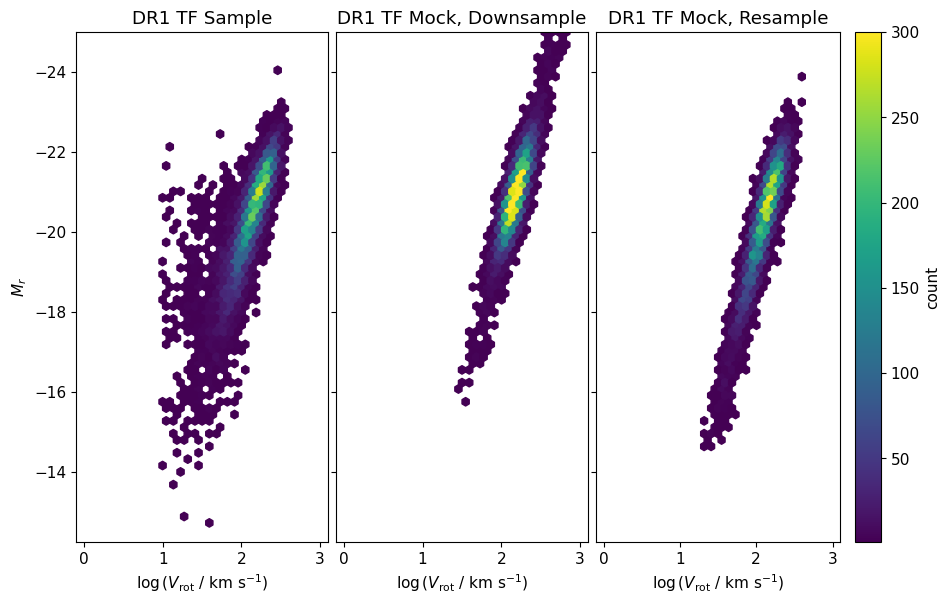

In [23]:
fig, axes = plt.subplots(1,3, figsize=(10,6), sharex=True, sharey=True,
                         gridspec_kw={'wspace':0.03, 'width_ratios':[0.825, 0.825,1]})

ax = axes[0]
ax.hexbin(tfrcat['logv_rot'][tfrcat['MAIN']], tfrcat['R_ABSMAG_SB26'][tfrcat['MAIN']],
          cmap='viridis', mincnt=1, 
          vmin=1, vmax=3e2,
          gridsize=(35,40), extent=(-0.1, 3.1, -25, -12.25))
ax.set(xlim=(-0.1,3.1),
       xlabel=r'$\log{(V_\mathrm{rot}~/~\mathrm{km~s}^{-1})}$',
       ylabel=r'$M_{r}$',
       ylim=(-12.25, -25),
       title=f'DR1 TF Sample')# ({tfr_version})');

# _log_v_rot = np.arange(-0.1, 3.05, 0.05)
# b0 = -5
# a0 = -7.16
# ax.plot(_log_v_rot, b0 + a0*_log_v_rot, ls='--', color='tab:red')

ax = axes[1]
h = ax.hexbin(mock_downsample['LOGVROT_MOCK'], mock_downsample['R_ABSMAG_SB26_MOCK'],
              cmap='viridis', mincnt=1, 
              vmin=1, vmax=3e2,
              gridsize=(35,40), extent=(-0.1, 3.1, -25, -12.25))
# cb = fig.colorbar(h, ax=ax, label='count')

ax.set(xlim=(-0.1,3.1),
       xlabel=r'$\log{(V_\mathrm{rot}~/~\mathrm{km~s}^{-1})}$',
       # ylabel=r'$M_{r,\mathrm{Y1}}$',
       ylim=(-12.25, -25),
       title=f'DR1 TF Mock, Downsample')

ax = axes[2]
h = ax.hexbin(mock_resample['LOGVROT_MOCK'], mock_resample['R_ABSMAG_SB26_MOCK'],
              cmap='viridis', mincnt=1, 
              vmin=1, vmax=3e2,
              gridsize=(35,40), extent=(-0.1, 3.1, -25, -12.25))
cb = fig.colorbar(h, ax=ax, label='count')

ax.set(xlim=(-0.1,3.1),
       xlabel=r'$\log{(V_\mathrm{rot}~/~\mathrm{km~s}^{-1})}$',
       # ylabel=r'$M_{r,\mathrm{Y1}}$',
       ylim=(-12.25, -25),
       title=f'DR1 TF Mock, Resample')

# _log_v_rot = np.arange(-0.1, 3.05, 0.05)
# b0 = -5
# a0 = -7.16
# ax.plot(_log_v_rot, b0 + a0*_log_v_rot, ls='--', color='tab:red')

fig.subplots_adjust(left=0.1, right=0.925, top=0.95, bottom=0.1)
# fig.savefig('TF_mock_dr1_relation.png', dpi=200)

mpl.rc('font', size=11);

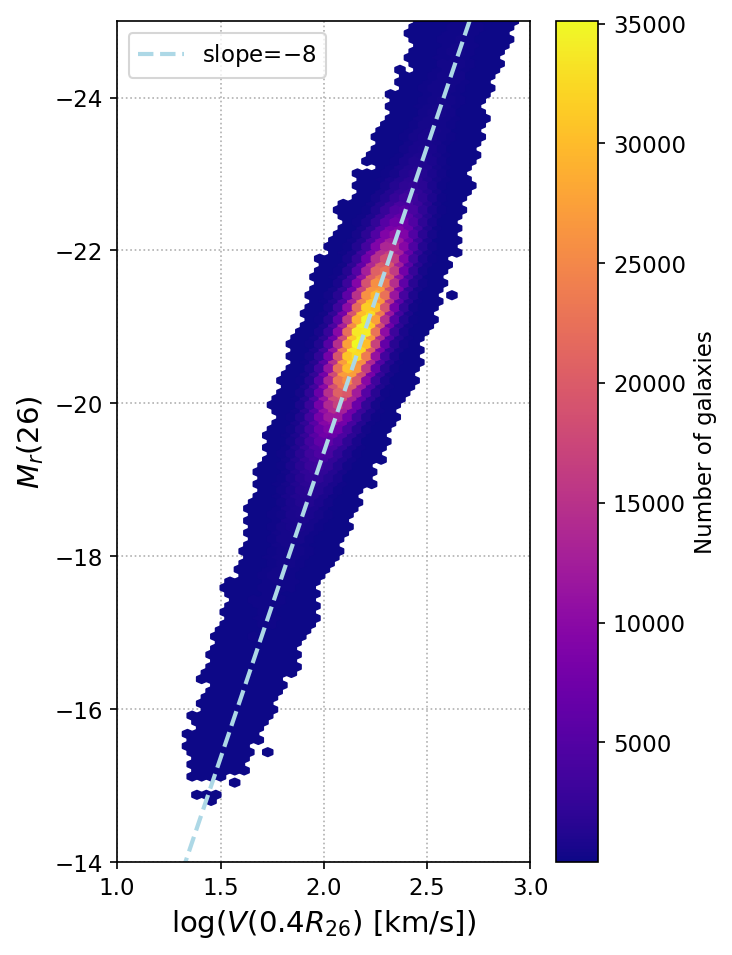

In [24]:
plt.figure(figsize=(5,6.5), tight_layout=True, facecolor='none', dpi=150)
plt.grid(ls=':')

# plt.errorbar(np.log10(sgatab['V_0p4R26'][outlier_boolean]), 
#              sgatab['R_ABSMAG_SB26'][outlier_boolean], 
#              xerr=0.434*sgatab['V_0p4R26_ERR'][outlier_boolean]/sgatab['V_0p4R26'][outlier_boolean],
#              yerr=sgatab['R_ABSMAG_SB26_ERR'][outlier_boolean], 
#              fmt='.',
#              color='gray',
#              alpha=0.1, 
#              ecolor='lightgray', zorder=1)

plt.hexbin(mock['LOGVROT_MOCK'], mock['R_ABSMAG_SB26_MOCK'], 
           cmap='plasma', 
           mincnt=2, 
           gridsize=(70,80), 
           extent=(-0.1, 3.1, -25, -12.25), zorder=2)
plt.colorbar(label='Number of galaxies')

_log_v_rot = np.arange(-0.1, 3.05, 0.05)
b0 = -3.36
a0 = -8
plt.plot(_log_v_rot, b0 + a0*_log_v_rot, ls='--', color='lightblue', lw=2, label=r'slope=$-8$')

# plt.errorbar([2.1], [-16], 
#              xerr=0,
#              yerr=sig, 
#              ecolor='tab:red', 
#              capsize=2)
# plt.annotate('Intrinsic \n dispersion', 
#              (3, -16), 
#              va='center',
#              ha='right',
#              c='gray',
#              fontsize=14)

plt.xlim([1, 3])
plt.ylim([-14, -25])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r(26)$', fontsize=14)
plt.legend()

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/tfr_hexbin_hyperfit.png', 
#             dpi=150, 
#             facecolor='none')

# Compare properties

## Read in DR2 BGS

In [24]:
def get_spec_file_name (healpix_index):
    # Fastspec fit files are split up into different healpix groups that cover differnt regions of the sky
    # There are 12 files total
    formated_index = str(healpix_index).zfill(2)
    
    file_name = f'/global/cfs/cdirs/desi/vac/dr2/fastspecfit/loa/v1.0/catalogs/fastspec-loa-main-bright-nside1-hp{formated_index}.fits'
    # file_name = f'/global/cfs/cdirs/desi/vac/dr1/fastspecfit/iron/v1.0/catalogs/fastspec-iron-main-bright-nside1-hp{formated_index}.fits'

    return file_name

bgs_catalog = Table(names = ['TARGETID','RA','DEC','Z',
                          'ABSMAG01_SDSS_G', 'ABSMAG01_SDSS_R', 'ABSMAG01_SDSS_Z',
                          'KCORR01_SDSS_G', 'KCORR01_SDSS_R', 'KCORR01_SDSS_Z'],
                   dtype =['>i8', '>f8', '>f8', '>f8','>f4', '>f4', '>f4', '>f4', '>f4', '>f4'])

#Open the FastSpecFit VAC
for idx in range (12): #12 bgs files total
    
    with fitsio.FITS(get_spec_file_name(idx)) as full_catalog:
        
        print("reading data", idx)
        metadata = full_catalog[1]['TARGETID','Z','ZWARN','DELTACHI2','SPECTYPE','RA','DEC','BGS_TARGET', 'SURVEY', 'PROGRAM'
                           ][:]
        specphot = full_catalog[2][
                           'ABSMAG01_SDSS_G',
                           'ABSMAG01_SDSS_R', 'ABSMAG01_SDSS_Z',
                           'KCORR01_SDSS_G', 'KCORR01_SDSS_R', 'KCORR01_SDSS_Z',
                          ][:]

        # fastspec = full_catalog[3]['HALPHA_EW',][:]


        catalog = rfn.merge_arrays([metadata, specphot], flatten=True, usemask=False)

        del metadata, specphot

        # SELECTION CUTS HAVE BEEN REMOVED FROM CODE FOR BREVITY 

        #save catalog
        out=Table([catalog['TARGETID'],
                   catalog['RA'],
                   catalog['DEC'],
                   catalog['Z'],
                   catalog['BGS_TARGET'],
                   catalog['ABSMAG01_SDSS_G'],
                   catalog['ABSMAG01_SDSS_R'],
                   catalog['ABSMAG01_SDSS_Z'],
                   catalog['KCORR01_SDSS_G'], 
                   catalog['KCORR01_SDSS_R'], 
                   catalog['KCORR01_SDSS_Z']
                  ],
                   
                   names=['TARGETID','RA','DEC','Z', 'BGS_TARGET',
                          'ABSMAG01_SDSS_G', 'ABSMAG01_SDSS_R', 'ABSMAG01_SDSS_Z',
                          'KCORR01_SDSS_G', 'KCORR01_SDSS_R', 'KCORR01_SDSS_Z']
                 )

        bgs_catalog = vstack([bgs_catalog, out])

reading data 0
reading data 1
reading data 2
reading data 3
reading data 4
reading data 5
reading data 6
reading data 7
reading data 8
reading data 9
reading data 10
reading data 11


In [25]:
bgs_catalog[:5]

TARGETID,RA,DEC,Z,ABSMAG01_SDSS_G,ABSMAG01_SDSS_R,ABSMAG01_SDSS_Z,KCORR01_SDSS_G,KCORR01_SDSS_R,KCORR01_SDSS_Z,BGS_TARGET
int64,float64,float64,float64,float32,float32,float32,float32,float32,float32,int64
39627797550862177,44.38318764682572,0.6091182656073019,0.36396769297864945,-19.87009,-20.648516,-21.284369,-0.6906548,0.087771334,-0.06983888,65537
39627797550864609,44.47422209242224,0.5998595900370475,0.393692991539963,-21.883978,-22.721489,-23.310635,-0.6640341,-0.6327667,-0.04362049,131074
39627803594850511,44.50520629495165,0.6520116523897986,0.2856185793107418,-21.181005,-22.099438,-22.826508,0.3192625,-0.08569749,-0.13751084,131074
39627803590660424,44.39607783924861,0.6739485795351126,0.16357518969630708,-19.400297,-20.007126,-20.589506,-0.036009993,-0.13435042,-0.12433953,131074
39627803590661230,44.4240911994552,0.6621351006538563,0.26793373876434595,-19.066122,-19.689056,-20.25884,0.22564197,-0.06376155,-0.09784353,65537


## Magnitude and color distributions

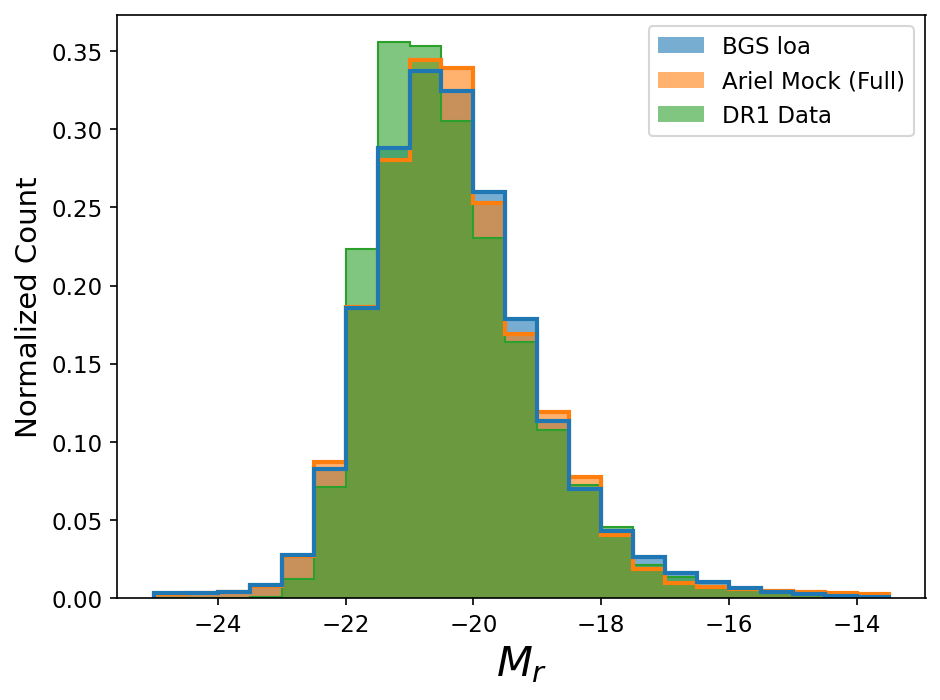

In [26]:
plt.figure(dpi=150, facecolor='none', tight_layout=True)
plt.hist(bgs_catalog['ABSMAG01_SDSS_R'], bins=np.arange(-25,-13,0.5), density=True, label='BGS loa',  alpha=0.6)#histtype='step', lw=2)
plt.hist(mock_full['R_ABSMAG_SB26_MOCK'], bins=np.arange(-25,-13,0.5), density=True, label='Ariel Mock (Full)',  alpha=0.6)#histtype='step', lw=2)
# plt.hist(mock_downsample['R_ABSMAG_SB26_MOCK'], bins=np.arange(-25,-13,0.5), density=True, alpha=0.5, label='Ariel Mock (Downsample)')
plt.hist(tfrcat['R_ABSMAG_SB26'], bins=np.arange(-25,-13,0.5), density=True, label='DR1 Data', alpha=0.6)# histtype='step', lw=2)
plt.hist(tfrcat['R_ABSMAG_SB26'], bins=np.arange(-25,-13,0.5), density=True, histtype='step', lw=1, color='tab:green')
plt.hist(mock_full['R_ABSMAG_SB26_MOCK'], bins=np.arange(-25,-13,0.5), density=True, histtype='step', color='tab:orange', lw=2)
plt.hist(bgs_catalog['ABSMAG01_SDSS_R'], bins=np.arange(-25,-13,0.5), density=True, histtype='step', lw=2, color='tab:blue')
plt.legend()
plt.xlabel(r'$M_r$', fontsize=20)
plt.ylabel(r'Normalized Count', fontsize=14)
plt.show()

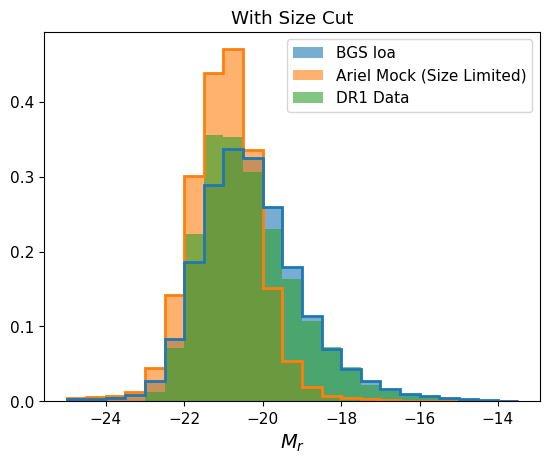

In [27]:
plt.figure()
plt.hist(bgs_catalog['ABSMAG01_SDSS_R'], bins=np.arange(-25,-13,0.5), density=True, label='BGS loa',  alpha=0.6)#histtype='step', lw=2)
plt.hist(mock['R_ABSMAG_SB26_MOCK'], bins=np.arange(-25,-13,0.5), density=True, label='Ariel Mock (Size Limited)',  alpha=0.6)#histtype='step', lw=2)
# plt.hist(mock_downsample['R_ABSMAG_SB26_MOCK'], bins=np.arange(-25,-13,0.5), density=True, alpha=0.5, label='Ariel Mock (Downsample)')
plt.hist(tfrcat['R_ABSMAG_SB26'], bins=np.arange(-25,-13,0.5), density=True, label='DR1 Data', alpha=0.6)# histtype='step', lw=2)
plt.hist(mock['R_ABSMAG_SB26_MOCK'], bins=np.arange(-25,-13,0.5), density=True, histtype='step', color='tab:orange', lw=2)
plt.hist(bgs_catalog['ABSMAG01_SDSS_R'], bins=np.arange(-25,-13,0.5), density=True, histtype='step', lw=2, color='tab:blue')
plt.legend()
plt.xlabel(r'$M_r$', fontsize=14)
plt.title('With Size Cut')
plt.show()

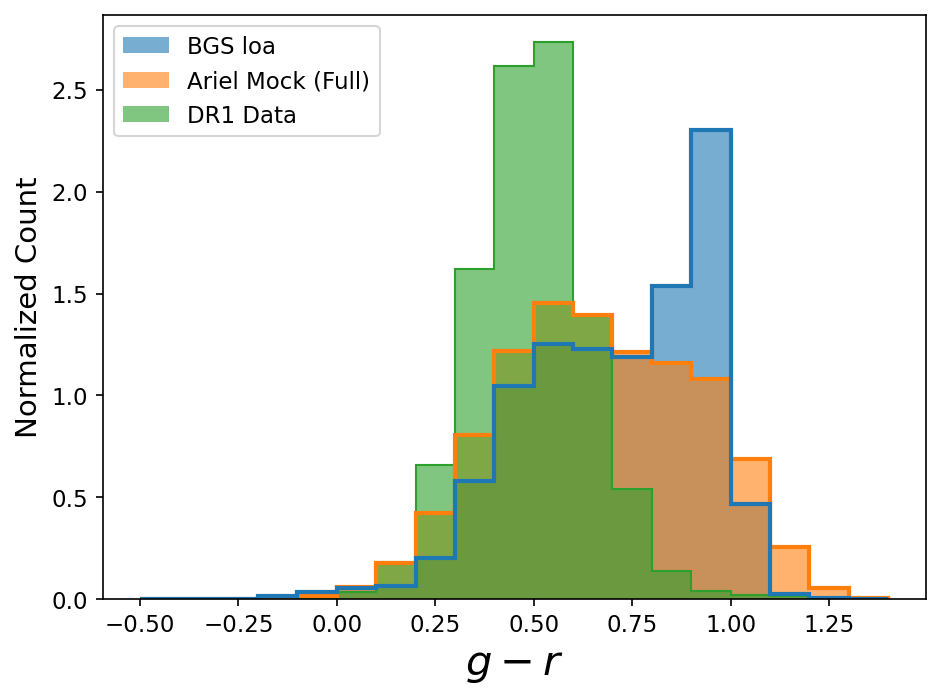

In [28]:
plt.figure(dpi=150, facecolor='none', tight_layout=True)
plt.hist(bgs_catalog['ABSMAG01_SDSS_G'] - bgs_catalog['ABSMAG01_SDSS_R'], bins=np.arange(-0.5,1.5,0.1), density=True, label='BGS loa',  alpha=0.6)#histtype='step', lw=2)
plt.hist(mock_full['g-r_obs'], bins=np.arange(-0.5,1.5,0.1), density=True, label='Ariel Mock (Full)',  alpha=0.6)#histtype='step', lw=2)
plt.hist(tfrcat['g-r'], bins=np.arange(-0.5,1.5,0.1), density=True, label='DR1 Data', alpha=0.6)# histtype='step', lw=2)

plt.hist(tfrcat['g-r'], bins=np.arange(-0.5,1.5,0.1), density=True,  histtype='step', color='tab:green')
plt.hist(mock_full['g-r_obs'], bins=np.arange(-0.5,1.5,0.1), density=True, histtype='step', color='tab:orange', lw=2)
plt.hist(bgs_catalog['ABSMAG01_SDSS_G'] - bgs_catalog['ABSMAG01_SDSS_R'], bins=np.arange(-0.5,1.5,0.1), density=True, histtype='step', lw=2, color='tab:blue')
plt.legend()
plt.xlabel(r'$g-r$', fontsize=20)
plt.ylabel(r'Normalized Count', fontsize=14)
plt.show()

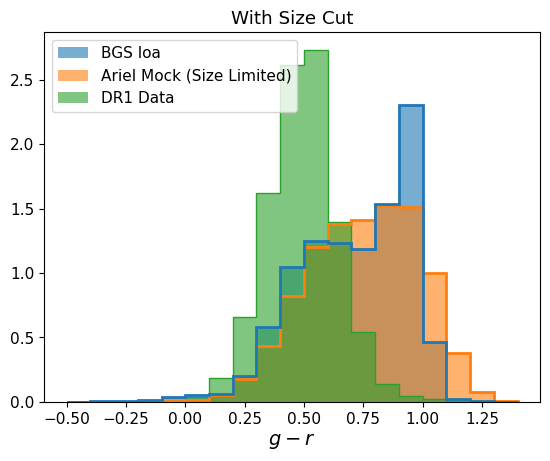

In [29]:
plt.figure()
plt.hist(bgs_catalog['ABSMAG01_SDSS_G'] - bgs_catalog['ABSMAG01_SDSS_R'], bins=np.arange(-0.5,1.5,0.1), density=True, label='BGS loa',  alpha=0.6)#histtype='step', lw=2)
plt.hist(mock['g-r_obs'], bins=np.arange(-0.5,1.5,0.1), density=True, label='Ariel Mock (Size Limited)',  alpha=0.6)#histtype='step', lw=2)
plt.hist(tfrcat['g-r'], bins=np.arange(-0.5,1.5,0.1), density=True, label='DR1 Data', alpha=0.6)# histtype='step', lw=2)

plt.hist(tfrcat['g-r'], bins=np.arange(-0.5,1.5,0.1), density=True,  histtype='step', color='tab:green')
plt.hist(mock['g-r_obs'], bins=np.arange(-0.5,1.5,0.1), density=True, histtype='step', color='tab:orange', lw=2)
plt.hist(bgs_catalog['ABSMAG01_SDSS_G'] - bgs_catalog['ABSMAG01_SDSS_R'], bins=np.arange(-0.5,1.5,0.1), density=True, histtype='step', lw=2, color='tab:blue')
plt.legend()
plt.xlabel(r'$g-r$', fontsize=14)
plt.title('With Size Cut')
plt.show()

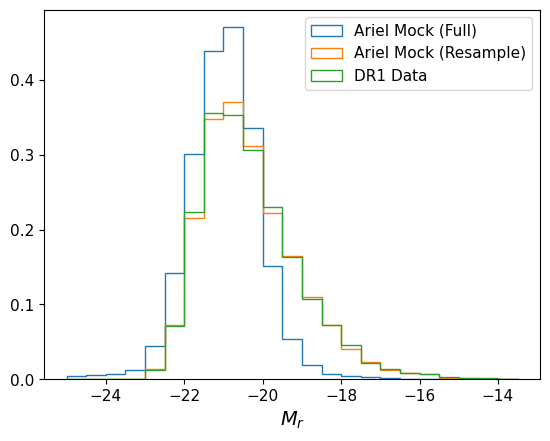

In [30]:
plt.figure()
plt.hist(mock['R_ABSMAG_SB26_MOCK'], bins=np.arange(-25,-13,0.5), density=True, label='Ariel Mock (Full)', histtype='step')
# plt.hist(mock_downsample['R_ABSMAG_SB26_MOCK'], bins=np.arange(-25,-13,0.5), density=True, alpha=0.5, label='Ariel Mock (Downsample)')
plt.hist(mock_resample['R_ABSMAG_SB26_MOCK'], bins=np.arange(-25,-13,0.5), density=True, label='Ariel Mock (Resample)', histtype='step')
plt.hist(tfrcat['R_ABSMAG_SB26'], bins=np.arange(-25,-13,0.5), density=True, label='DR1 Data', histtype='step')
plt.legend()
plt.xlabel(r'$M_r$', fontsize=14)
plt.show()

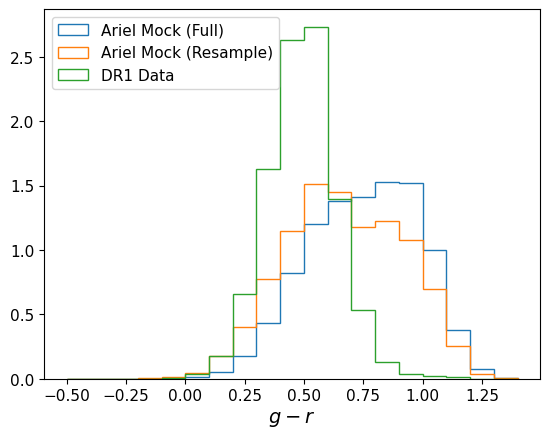

In [31]:
plt.figure()
plt.hist(mock['g-r_obs'], bins=np.arange(-0.5,1.5,0.1), density=True, histtype='step', label='Ariel Mock (Full)')
plt.hist(mock_resample['g-r_obs'], bins=np.arange(-0.5,1.5,0.1), density=True, histtype='step', label='Ariel Mock (Resample)')
plt.hist(tfrcat['G_MAG_SB26_CORR'][tfrcat['MAIN']] - tfrcat['R_MAG_SB26_CORR'][tfrcat['MAIN']], bins=np.arange(-0.5,1.5,0.1), density=True, histtype='step', label='DR1 Data')
# plt.hist(tfrcat['G_MAG_SB26_CORR'] - tfrcat['R_MAG_SB26_CORR'], bins=np.arange(-0.5,1.5,0.1), density=True, histtype='step', label='DR1 Data- no cuts')
plt.legend()
plt.xlabel(r'$g-r$', fontsize=14)
plt.show()

### What happens if we downsample in color bins to make the mock match the distribution of g-r in the data

In [32]:
def color_resample(mock, data, size=100, color_col_mock='g-r_obs',
             color_col_data='g-r', bins=20, random_state=None):
    """
    Downsample a mock catalog to match the absolute magnitude distribution
    of a data catalog.

    Parameters
    ----------
    mock : pandas.DataFrame
        Mock catalog.
    data : pandas.DataFrame
        Data catalog (e.g., tfrcat).
    size : int
        Desired number of objects in output sample.
    color_col_mock : str
        Column name for absolute magnitude in mock.
    color_col_data : str
        Column name for absolute magnitude in data.
    bins : int or array-like
        Number of bins or bin edges for magnitude.
    random_state : int or None
        Random seed.

    Returns
    -------
    newmock : pandas.DataFrame
        Resampled mock catalog matching data distribution.
    """

    rng = np.random.default_rng(random_state)

    # Drop NaNs
    mock_vals = mock[color_col_mock].values
    data_vals = data[color_col_data].values

    valid_mock = np.isfinite(mock_vals)
    valid_data = np.isfinite(data_vals)

    mock = mock.loc[valid_mock].copy()
    data_vals = data_vals[valid_data]

    # Define bins based on data
    hist_data, bin_edges = np.histogram(data_vals, bins=bins)

    # Convert to probabilities
    prob_data = hist_data / hist_data.sum()

    # Assign each mock galaxy to a bin
    mock_bins = np.digitize(mock[color_col_mock], bin_edges) - 1

    sampled_indices = []

    for i in range(len(bin_edges) - 1):
        # indices in this bin
        idx_in_bin = np.where(mock_bins == i)[0]

        if len(idx_in_bin) == 0:
            continue

        # number to draw from this bin
        n_draw = int(np.round(prob_data[i] * size))

        if n_draw == 0:
            continue

        # sample (without replacement if possible)
        replace = n_draw > len(idx_in_bin)
        chosen = rng.choice(idx_in_bin, size=n_draw, replace=replace)

        sampled_indices.extend(chosen)

    # If we are short/excess due to rounding, fix it
    if len(sampled_indices) < size:
        remaining = size - len(sampled_indices)
        extra = rng.choice(len(mock), size=remaining, replace=False)
        sampled_indices.extend(extra)
    elif len(sampled_indices) > size:
        sampled_indices = rng.choice(sampled_indices, size=size, replace=False)

    return mock.iloc[sampled_indices].reset_index(drop=True)

In [33]:
tfrcat['g-r'] = tfrcat['G_MAG_SB26_CORR']- tfrcat['R_MAG_SB26_CORR']
mock_color_resample = color_resample(mock, tfrcat[tfrcat['MAIN']], Ntfr)
mock_full_color_resample = color_resample(mock_full, tfrcat[tfrcat['MAIN']], Ntfr)

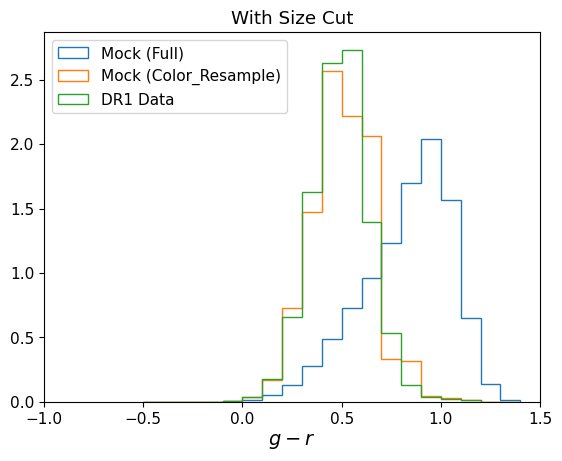

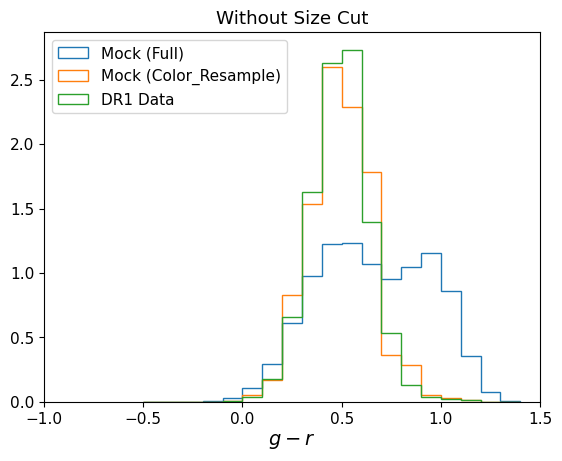

In [34]:
plt.figure()
plt.hist(mock['g-r_obs'], bins=np.arange(-0.5,1.5,0.1), density=True, histtype='step', label='Mock (Full)')
plt.hist(mock_color_resample['g-r_obs'], bins=np.arange(-0.5,1.5,0.1), density=True, histtype='step', label='Mock (Color_Resample)')
plt.hist(tfrcat['G_MAG_SB26_CORR'][tfrcat['MAIN']] - tfrcat['R_MAG_SB26_CORR'][tfrcat['MAIN']], bins=np.arange(-0.5,1.5,0.1), density=True, histtype='step', label='DR1 Data')
# plt.hist(tfrcat['G_MAG_SB26_CORR'] - tfrcat['R_MAG_SB26_CORR'], bins=np.arange(-0.5,1.5,0.1), density=True, histtype='step', label='DR1 Data- no cuts')
plt.legend()
plt.xlabel(r'$g-r$', fontsize=14)
plt.title('With Size Cut')
plt.xlim(-1,1.5)
plt.show()

plt.figure()
plt.hist(mock_full['g-r_obs'], bins=np.arange(-0.5,1.5,0.1), density=True, histtype='step', label='Mock (Full)')
plt.hist(mock_full_color_resample['g-r_obs'], bins=np.arange(-0.5,1.5,0.1), density=True, histtype='step', label='Mock (Color_Resample)')
plt.hist(tfrcat['G_MAG_SB26_CORR'][tfrcat['MAIN']] - tfrcat['R_MAG_SB26_CORR'][tfrcat['MAIN']], bins=np.arange(-0.5,1.5,0.1), density=True, histtype='step', label='DR1 Data')
# plt.hist(tfrcat['G_MAG_SB26_CORR'] - tfrcat['R_MAG_SB26_CORR'], bins=np.arange(-0.5,1.5,0.1), density=True, histtype='step', label='DR1 Data- no cuts')
plt.legend()
plt.xlabel(r'$g-r$', fontsize=14)
plt.title('Without Size Cut')
plt.xlim(-1,1.5)
plt.show()

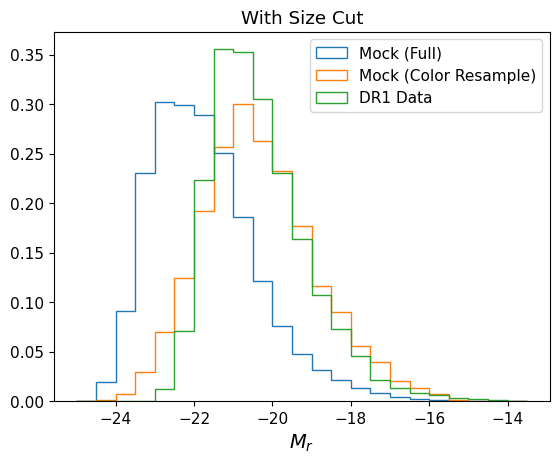

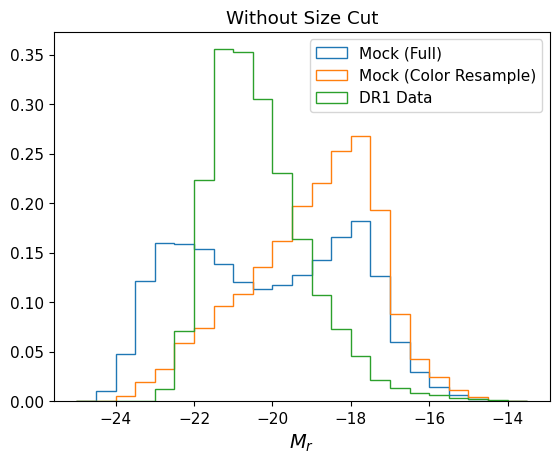

In [35]:
plt.figure()
plt.hist(mock['R_ABSMAG_SB26_MOCK'], bins=np.arange(-25,-13,0.5), density=True, label='Mock (Full)', histtype='step')
# plt.hist(mock_downsample['R_ABSMAG_SB26_MOCK'], bins=np.arange(-25,-13,0.5), density=True, alpha=0.5, label='Ariel Mock (Downsample)')
plt.hist(mock_color_resample['R_ABSMAG_SB26_MOCK'], bins=np.arange(-25,-13,0.5), density=True, label='Mock (Color Resample)', histtype='step')
plt.hist(tfrcat['R_ABSMAG_SB26'], bins=np.arange(-25,-13,0.5), density=True, label='DR1 Data', histtype='step')
plt.legend()
plt.title('With Size Cut')
plt.xlabel(r'$M_r$', fontsize=14)
plt.show()

plt.figure()
plt.hist(mock_full['R_ABSMAG_SB26_MOCK'], bins=np.arange(-25,-13,0.5), density=True, label='Mock (Full)', histtype='step')
# plt.hist(mock_downsample['R_ABSMAG_SB26_MOCK'], bins=np.arange(-25,-13,0.5), density=True, alpha=0.5, label='Ariel Mock (Downsample)')
plt.hist(mock_full_color_resample['R_ABSMAG_SB26_MOCK'], bins=np.arange(-25,-13,0.5), density=True, label='Mock (Color Resample)', histtype='step')
plt.hist(tfrcat['R_ABSMAG_SB26'], bins=np.arange(-25,-13,0.5), density=True, label='DR1 Data', histtype='step')
plt.legend()
plt.title('Without Size Cut')
plt.xlabel(r'$M_r$', fontsize=14)
plt.show()

## Color distribution in SGA

In [36]:
SGA = Table.read('/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits', 'ELLIPSE')

In [38]:
healpix = Table.read('../../Y3/desi_pv_loa_healpix.fits')
print(len(healpix))
healpix['SGA_ID'] = healpix['SGA_ID'].astype(int)
healpix = healpix[healpix['SGA_ID'] >=0]
print(len(healpix))

rng = np.random.default_rng()
N_samples = 10000 # for large error propagation
SGA_dict = {}

for i in range(len(SGA)):
    
    SGA_dict[SGA['SGA_ID'][i]] = i

healpix['SKY_FIBER_DIST'] = 0.
healpix['SKY_FIBER_DIST_R26'] = 0.

# For each SGA galaxy that has at least one observation, calculate the distance 
# for all of that galaxy's targets
for sga_id in tqdm(np.unique(healpix['SGA_ID'])):
    
    # Identify all galaxy targets on this galaxy
    obs_idx = healpix['SGA_ID'] == sga_id
    
    # Find galaxy index in SGA catalog
    sga_idx = SGA_dict[sga_id]
    
    #---------------------------------------------------------------------------
    # Calculate distance between each observation and the center of the SGA 
    # galaxy
    #---------------------------------------------------------------------------
    SGA_coords = SkyCoord(ra=SGA['RA'][sga_idx], 
                          dec=SGA['DEC'][sga_idx], 
                          unit=u.degree)
    target_coords = SkyCoord(ra=healpix['TARGET_RA'][obs_idx], 
                             dec=healpix['TARGET_DEC'][obs_idx], 
                             unit=u.degree)
    
    sep2d = target_coords.separation(SGA_coords)
    
    healpix['SKY_FIBER_DIST'][obs_idx] = sep2d
    healpix['SKY_FIBER_DIST_R26'][obs_idx] = 2*sep2d.to('arcmin')/(SGA['D26'][sga_idx]*u.arcmin)
    #---------------------------------------------------------------------------

centers_boolean = healpix['SKY_FIBER_DIST_R26'] < 0.1
iron_centers = healpix[centers_boolean]

561829
309932


100%|██████████| 210798/210798 [13:47<00:00, 254.75it/s]


In [ ]:
SGA['Z_DESI'] = np.nan
SGA['ZERR_DESI'] = np.nan

# weights = 1./(good_centers_VI['ZERR']**2)
weights = 1./(iron_centers['ZERR']**2)

for sga_id in tqdm(np.unique(iron_centers['SGA_ID'])):
    
    # Find all the center observations of this galaxy
    obs_idx = iron_centers['SGA_ID'] == sga_id
    N_obs = np.sum(obs_idx)
    
    # Find the row in SGA for this galaxy
    SGA_idx = SGA_dict[sga_id]
    
    # Set the redshift of this galaxy to be the weighted average redshift of all 
    # good center observations
    SGA['Z_DESI'][SGA_idx] = np.average(iron_centers['Z'][obs_idx], 
                                        weights=weights[obs_idx])

    # Compute the uncertainty in the center redshift
    # if (N_obs == 1) or np.all(np.abs(good_centers_VI['ZERR_MOD'][obs_idx]/good_centers_VI['Z'][obs_idx]) < 0.05):
    #     SGA['ZERR_DESI'][SGA_idx] = np.sqrt(1/np.sum(weights[obs_idx]))
    # else:
    z_random = np.zeros((N_obs, N_samples))

    for i in range(N_obs):
        z_random[i] = rng.normal(loc=iron_centers['Z'][obs_idx][i], 
                                 scale=iron_centers['ZERR'][obs_idx][i], 
                                 size=N_samples)

    avg_z_random = np.average(z_random, 
                              weights=weights[obs_idx,None]*np.ones(N_samples), 
                              axis=0)
    SGA['ZERR_DESI'][SGA_idx] = np.std(avg_z_random)

In [ ]:
SGA['Z_DESI_CMB'] = convert_z_frame(SGA['Z_DESI'], SGA['RA'], SGA['DEC'])

In [ ]:
morphs = Table.read('/global/cfs/cdirs/desi/science/td/pv/SGA2020/final_classifications_SGA2020.csv')
morphs['SGA_ID'] = morphs['SGA_ID'].astype(int)
SGA = join(SGA, morphs)

In [ ]:
np.sum(SGA['Classification']=='Elliptical'), np.sum(SGA['Classification']=='Spiral')

In [ ]:
SGA = SGA[SGA['Z_DESI'] < 0.5]

### Photometric Corrections

In [ ]:
# Import E(B-V) dust map
ebv_directory = '/global/cfs/cdirs/desicollab/users/rongpu/dust/desi_ebv/public_data/maps/'
# ebv_directory = '/Users/kdouglass/Documents/Research/data/DESI/'
ebv_filename = 'desi_dust_gr_512.fits'
ebv_map = Table.read(ebv_directory + ebv_filename)

In [ ]:
MWdust_corr, MWdust_corr_err = MW_dust(SGA['RA'], SGA['DEC'], ebv_map)

In [ ]:
# Flip NaN values to 0
MWdust_corr_err[np.isnan(MWdust_corr_err)] = 0

In [ ]:
# Apparently we have some galaxies with negative redshifts
zg0 = SGA['Z_DESI'] >= 0

In [ ]:
kcorr_zg0 = k_corr(SGA['Z_DESI'][zg0], 
                   [SGA['G_MAG_SB26'][zg0], SGA['R_MAG_SB26'][zg0], SGA['Z_MAG_SB26'][zg0]], 
                   [SGA['G_MAG_SB26_ERR'][zg0], SGA['R_MAG_SB26_ERR'][zg0], SGA['Z_MAG_SB26_ERR'][zg0]], 
                   # z_corr=0.1) # K-correcting to same redshift as FastSpecFit (which is what Caitlin's using for the FP)
                   z_corr=0.1)

In [ ]:
plt.hist(SGA['Z_DESI'])

In [ ]:
kcorr = np.zeros([len(SGA), 3])
kcorr[zg0] = kcorr_zg0

In [ ]:
# temp_infile = open('../iron_internalDust_z0p1_mcmc_04202026.pickle', 'rb')
temp_infile = open('/pscratch/sd/s/sgmoore1/TF/pickles/iron_internalDust_z0p1_mcmc_04232026.pickle', 'rb')
# temp_infile = open('/pscratch/sd/s/sgmoore1/TF/pickles/iron_internalDust_z0p05_mcmc_04232026.pickle', 'rb')
dust_mcmc_samples_r,_, dust_mcmc_samples_g,_, dust_mcmc_samples_z,_ = pickle.load(temp_infile)
temp_infile.close()

In [ ]:
internalDust_coeffs_r = np.median(dust_mcmc_samples_r, axis=1)
internalDust_coeffs_g = np.median(dust_mcmc_samples_g, axis=1)
internalDust_coeffs_z = np.median(dust_mcmc_samples_z, axis=1)

internalDust_coeffs_err_r = np.zeros(len(internalDust_coeffs_r))
internalDust_coeffs_err_g = np.zeros(len(internalDust_coeffs_g))
internalDust_coeffs_err_z = np.zeros(len(internalDust_coeffs_z))

internalDust_coeffs_err_r[0] = np.std(dust_mcmc_samples_r[0][(-1.5 < dust_mcmc_samples_r[0]) & (dust_mcmc_samples_r[0] < 0)])
internalDust_coeffs_err_r[1] = np.std(dust_mcmc_samples_r[1][(0 < dust_mcmc_samples_r[1]) & (dust_mcmc_samples_r[1] < 1)])

internalDust_coeffs_err_g[0] = np.std(dust_mcmc_samples_g[0][(-1.5 < dust_mcmc_samples_g[0]) & (dust_mcmc_samples_g[0] < 0)])
internalDust_coeffs_err_g[1] = np.std(dust_mcmc_samples_g[1][(0 < dust_mcmc_samples_g[1]) & (dust_mcmc_samples_g[1] < 1)])

internalDust_coeffs_err_z[0] = np.std(dust_mcmc_samples_z[0][(-1.5 < dust_mcmc_samples_z[0]) & (dust_mcmc_samples_z[0] < 0)])
internalDust_coeffs_err_z[1] = np.std(dust_mcmc_samples_z[1][(0 < dust_mcmc_samples_z[1]) & (dust_mcmc_samples_z[1] < 1)])

In [ ]:
internalDust_corr_r, internalDust_corr_err_r = internal_dust(SGA['BA'], 
                                                             internalDust_coeffs_r, 
                                                             internalDust_coeffs_err_r)

internalDust_corr_g, internalDust_corr_err_g = internal_dust(SGA['BA'], 
                                                             internalDust_coeffs_g, 
                                                             internalDust_coeffs_err_g)

internalDust_corr_z, internalDust_corr_err_z = internal_dust(SGA['BA'], 
                                                             internalDust_coeffs_z, 
                                                             internalDust_coeffs_err_z)

## Apply corrections

In [ ]:
SGA['G_MAG_SB26_CORR'] = SGA['G_MAG_SB26'] - MWdust_corr[0] - kcorr[:,0] - internalDust_corr_g
SGA['R_MAG_SB26_CORR'] = SGA['R_MAG_SB26'] - MWdust_corr[1] - kcorr[:,1] - internalDust_corr_r
SGA['Z_MAG_SB26_CORR'] = SGA['Z_MAG_SB26'] - MWdust_corr[2] - kcorr[:,2] - internalDust_corr_z

In [ ]:
SGA['G_MAG_SB26_ERR_CORR'] = np.sqrt(SGA['G_MAG_SB26_ERR']**2 + MWdust_corr_err[0]**2 + internalDust_corr_err_g**2)
SGA['R_MAG_SB26_ERR_CORR'] = np.sqrt(SGA['R_MAG_SB26_ERR']**2 + MWdust_corr_err[1]**2 + internalDust_corr_err_r**2)
SGA['Z_MAG_SB26_ERR_CORR'] = np.sqrt(SGA['Z_MAG_SB26_ERR']**2 + MWdust_corr_err[2]**2 + internalDust_corr_err_z**2)

In [ ]:
Planck18_h = FlatLambdaCDM(H0=100, Om0=0.3151)
SGA['MU_ZCMB'] = Planck18_h.distmod(SGA['Z_DESI_CMB'])
SGA['R_ABSMAG_SB26'] = SGA['R_MAG_SB26_CORR'] - SGA['MU_ZCMB'].value

In [ ]:
np.sum(SGA['Classification']=='Elliptical'), np.sum(SGA['Classification']=='Spiral')

In [ ]:
plt.figure()
# plt.hist(SGA['R_ABSMAG_SB26'], bins=np.arange(-25,-13,0.5), density=True, label='SGA (Full)', histtype='step')
plt.hist(SGA['R_ABSMAG_SB26'][SGA['Classification']=='Elliptical'], bins=np.arange(-25,-13,0.5), density=True, label='Elliptical (49474)', histtype='step')
plt.hist(SGA['R_ABSMAG_SB26'][SGA['Classification']=='Spiral'], bins=np.arange(-25,-13,0.5), density=True, label='Spiral (87570)', histtype='step')

plt.legend()
plt.title('SGA Galaxies in Loa')
plt.xlabel(r'$M_r$', fontsize=14)
plt.ylabel('Normalized Count')
plt.show()

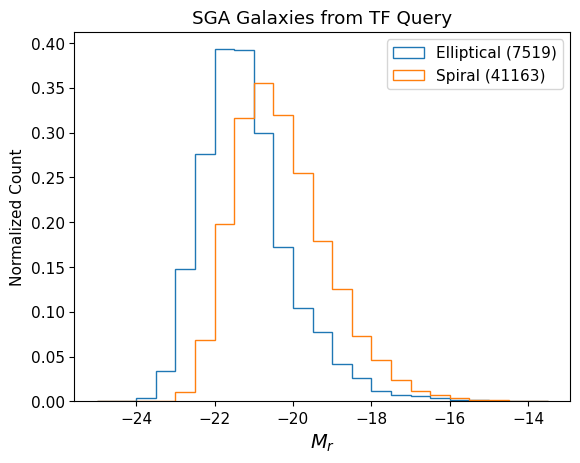

In [145]:
# plt.figure()
# # plt.hist(SGA['R_ABSMAG_SB26'], bins=np.arange(-25,-13,0.5), density=True, label='SGA (Full)', histtype='step')
# plt.hist(SGA['R_ABSMAG_SB26'][SGA['Classification']=='Elliptical'], bins=np.arange(-25,-13,0.5), density=True, label='Elliptical (7519)', histtype='step')
# plt.hist(SGA['R_ABSMAG_SB26'][SGA['Classification']=='Spiral'], bins=np.arange(-25,-13,0.5), density=True, label='Spiral (41163)', histtype='step')

# plt.legend()
# plt.title('SGA Galaxies from TF Query')
# plt.xlabel(r'$M_r$', fontsize=14)
# plt.ylabel('Normalized Count')
# plt.show()